In [63]:
from typing import TypedDict, Annotated, Literal, List, Optional
from pydantic import BaseModel
from langchain_ollama import ChatOllama
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, RemoveMessage
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.base import BaseStore
from langchain_core.runnables import RunnableConfig
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langgraph.types import interrupt, Command
from langgraph.graph import StateGraph, START, END

In [80]:
class State(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    user_input: str  
    proposed_trade: Optional[str]
    user_decision: Optional[Literal["approve", "reject", "modify"]]
    user_feedback: Optional[str]

class ResearchState(TypedDict):
    company: str
    memo: str

llm = ChatOllama(model="llama3.1")

In [65]:
@tool
def earning_reports(query: str) -> str:
    """Tool that gives the COMPANY'S EARNING REPORTS AND RECENT MARKET NEWS"""
    return "The company's earnings this year are in profit and the latest market news is favorable."

llm_with_tools = llm.bind_tools([earning_reports])

# --- 3. RESEARCH SUB-GRAPH ---
def fetch_data(state: ResearchState):
    data = earning_reports.invoke({"query": state["company"]})
    return {"memo": f"Data: {data}"}

def generate_memo(state: ResearchState):
    memo = f"Investment Memo for {state['company']}: {state['memo']} Analysis shows strong potential."
    return {"memo": memo}

research_builder = StateGraph(ResearchState)
research_builder.add_node("fetch_data", fetch_data)
research_builder.add_node("generate_memo", generate_memo)
research_builder.add_edge(START, "fetch_data")
research_builder.add_edge("fetch_data", "generate_memo")
research_builder.add_edge("generate_memo", END)
research_subgraph = research_builder.compile()

In [66]:
def validate_query(state: State) -> State:
    """Appends the initial user_input to the message history."""
    return {"messages": [HumanMessage(content=state["user_input"])]}

def check_query_route(state: State) -> Literal["chat_node", "exit_message"]:
    """Conditional edge router: Does not mutate state."""
    prompt = f"""You are a Finance Assistant. Given the query, is it related to finance/trading?
    Query: {state["user_input"]}
    Rules: return "valid" or "invalid"."""
    response = llm.invoke(prompt)
    if "invalid" in response.content.lower():
        return "exit_message"
    return "chat_node"

In [67]:
def chat_node(state: State, config: RunnableConfig, store: BaseStore) -> State:
    user_id = config["configurable"]["user_id"]
    
    # Correct Store API implementation
    portfolio_item = store.get(namespace=("users", user_id), key="portfolio")
    risk_item = store.get(namespace=("users", user_id), key="risk")
    summary_item = store.get(namespace=("users", user_id), key="summary")
    
    portfolio = portfolio_item.value if portfolio_item else "No portfolio set"
    risk = risk_item.value if risk_item else "Moderate"
    summary = summary_item.value.get("summary") if summary_item else "No past interaction"

    prompt = f"""You are a Finance assistant.
    Conversation: {state['messages']}
    Portfolio: {portfolio} | Risk: {risk} | Summary: {summary}
    If the user wants research on a stock, output strictly: "RESEARCH: <company_name>".
    Otherwise, assist normally."""
    
    response = llm_with_tools.invoke(prompt)
    return {"messages": [response]}  

In [68]:
def routing_node(state: State):
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tool_node"
    if isinstance(last_message.content, str) and "RESEARCH" in last_message.content:
        return "research_node"
    return "should_trade"

In [69]:
def research_wrapper(state: State):
    """Bridges the main graph and the research sub-graph."""
    last_content = state["messages"][-1].content
    company = last_content.replace("RESEARCH:", "").strip()
    
    result = research_subgraph.invoke({"company": company, "memo": ""})
    return {"messages": [AIMessage(content=result["memo"])]}

In [70]:
def should_trade(state: State, config: RunnableConfig, store: BaseStore) -> State:
    user_id = config["configurable"]["user_id"]
    risk_item = store.get(namespace=("users", user_id), key="risk")
    risk_cap = risk_item.value if risk_item else "Moderate"

    prompt = f"""Based on history: {state['messages']} and feedback: {state.get('user_feedback', '')}. 
    Propose a trade. If no trade is needed, say 'None'."""
    response = llm.invoke(prompt)
    proposed_trade = response.content

    return {"proposed_trade": proposed_trade}

In [71]:
def route_to_ask(state: State):
    if state.get("proposed_trade") and "none" not in state["proposed_trade"].lower():
        return "ask_node"
    return "summarize"

def ask_node(state: State) -> State:
    """HITL interruption node."""
    decision_data = interrupt({
        "type": "human_approval",
        "proposed_trade": state.get("proposed_trade")
    })
    
    # Properly parses the dictionary injected by Command(resume=...)
    return {
        "user_decision": decision_data.get("decision", "modify"),
        "user_feedback": decision_data.get("feedback", "")
    }

In [72]:
def route_decision(state: State):
    decision = state.get("user_decision", "modify").lower()
    if decision == "approve":
        return "trading_msg"
    elif decision == "reject":
        return "summarize"
    else:
        return "should_trade"

In [73]:
def summarize_node(state: State, config: RunnableConfig, store: BaseStore) -> State:
    user_id = config["configurable"]["user_id"]
    summary_item = store.get(namespace=("users", user_id), key="summary")
    summary = summary_item.value.get("summary") if summary_item else "None"
    
    prompt = f"Summarize concisely:\nHistory: {state['messages']}\nPast summary: {summary}"
    new_summary = llm.invoke(prompt).content
    
    # Correct Store 'put' implementation
    store.put(namespace=("users", user_id), key="summary", value={"summary": new_summary})
    return {}

In [74]:
def trimming(state: State) -> State:
    messages = state['messages']
    if len(messages) > 6:
        return {"messages": [RemoveMessage(id=m.id) for m in messages[:-6]]}
    return {}

def trading_message(state: State):
    return {"messages": [AIMessage(content=f"Trade executed: {state.get('proposed_trade')}")]}

def exit_message(state: State):
    return {"messages": [AIMessage(content="We only accept queries regarding Finance. Exiting...")]}


In [75]:
store = InMemoryStore()
saver = InMemorySaver()
builder = StateGraph(State)

builder.add_node("validate_query", validate_query)
builder.add_node("exit_message", exit_message)
builder.add_node("chat_node", chat_node)
builder.add_node("tool_node", ToolNode([earning_reports]))
builder.add_node("research_node", research_wrapper)
builder.add_node("should_trade", should_trade)
builder.add_node("ask_node", ask_node)
builder.add_node("summarize", summarize_node)
builder.add_node("trim", trimming)
builder.add_node("trading_msg", trading_message)

builder.add_edge(START, "validate_query")
builder.add_conditional_edges(
    "validate_query", 
    check_query_route, 
    {"chat_node": "chat_node", "exit_message": "exit_message"}
)
builder.add_edge("exit_message", END)

builder.add_conditional_edges(
    "chat_node", 
    routing_node, 
    {
        "tool_node": "tool_node",
        "research_node": "research_node",
        "should_trade": "should_trade"
    }
)
builder.add_edge("tool_node", "chat_node")
builder.add_edge("research_node", "should_trade")

builder.add_conditional_edges(
    "should_trade",
    route_to_ask,
    {"ask_node": "ask_node", "summarize": "summarize"}
)

builder.add_conditional_edges(
    "ask_node", 
    route_decision, 
    {
        "trading_msg": "trading_msg",
        "summarize": "summarize",
        "should_trade": "should_trade"
    }
)

builder.add_edge("trading_msg", "summarize")
builder.add_edge("summarize", "trim")
builder.add_edge("trim", END)

graph = builder.compile(checkpointer=saver, store=store)

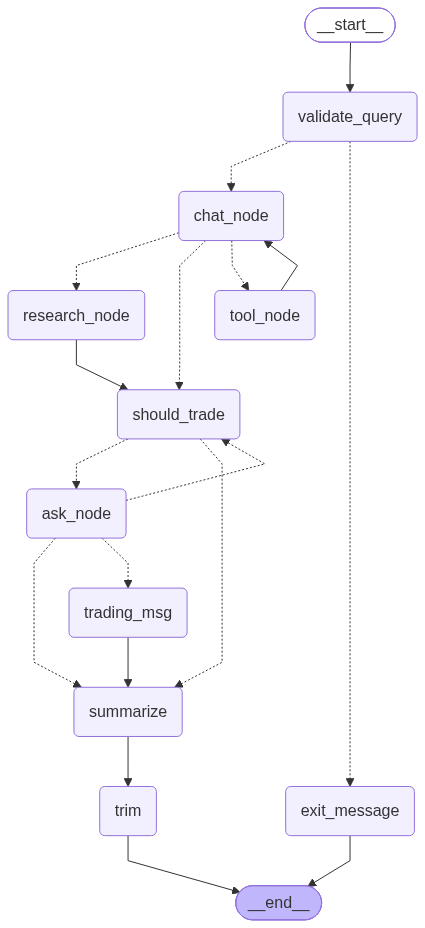

In [76]:
graph

In [81]:
config = {"configurable": {"thread_id": "1", "user_id": "user_123"}}

# 1. Run the graph initially
for event in graph.stream({"user_input": "Research AAPL and buy 10 shares"}, config):
    print(event)

# 2. The graph will yield/pause at `ask_node`. Check the state:
print(graph.get_state(config).next)

# 3. Resume the graph with your decision
resume_data = {"decision": "approve", "feedback": "Looks good to me."}
for event in graph.stream(Command(resume=resume_data), config):
    print(event)

{'validate_query': {'messages': [HumanMessage(content='Research AAPL and buy 10 shares', additional_kwargs={}, response_metadata={}, id='eb830d61-7349-4ae9-95ca-225b131226b7')]}}
{'exit_message': {'messages': [AIMessage(content='We only accept queries regarding Finance. Exiting...', additional_kwargs={}, response_metadata={}, id='fc4420ff-074d-4526-b3f1-0d74bb9b29f4', tool_calls=[], invalid_tool_calls=[])]}}
()
